# 客户满意度分析

本笔记本分析客户评价评分分布、评分与商品类别/消费金额/购买频率的关系。
- 评价评分分布
- 评分与商品类别的关系
- 评分与消费金额的关联
- 不同购买频率客户的满意度

## 分析目标
洞察客户满意度，优化服务和产品体验。

## 数据导入与预处理

导入数据，筛选满意度相关字段（评分、类别、金额、频率），并检查缺失值。

In [1]:
# 导入库和数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')

# 选取满意度相关字段
sat_cols = ['Review Rating', 'Category', 'Purchase Amount (USD)', 'Frequency of Purchases']
df_sat = df[sat_cols]

# 检查缺失值
print(df_sat.isnull().sum())

Review Rating             0
Category                  0
Purchase Amount (USD)     0
Frequency of Purchases    0
dtype: int64


## 评价评分分布分析

统计客户评价评分分布，展示满意度整体水平。

d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packa

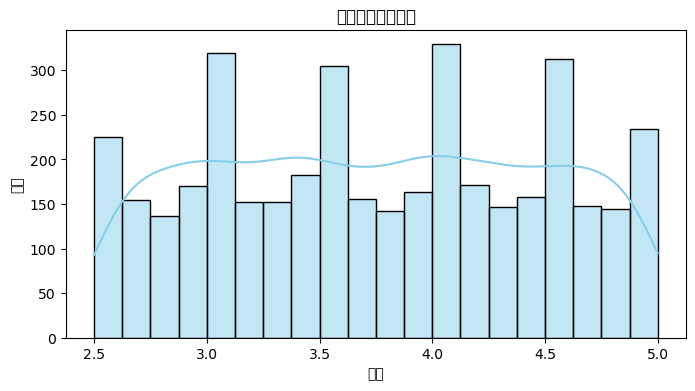

In [2]:
# 评分分布直方图
plt.figure(figsize=(8,4))
sns.histplot(df['Review Rating'], bins=20, kde=True, color='skyblue')
plt.title('客户评价评分分布')
plt.xlabel('评分')
plt.ylabel('人数')
plt.show()

## 评分与商品类别的关系分析

分析不同商品类别的平均评分，展示类别满意度差异。

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_34932\96836282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Review Rating', data=cat_rating, palette='Set2')
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2099

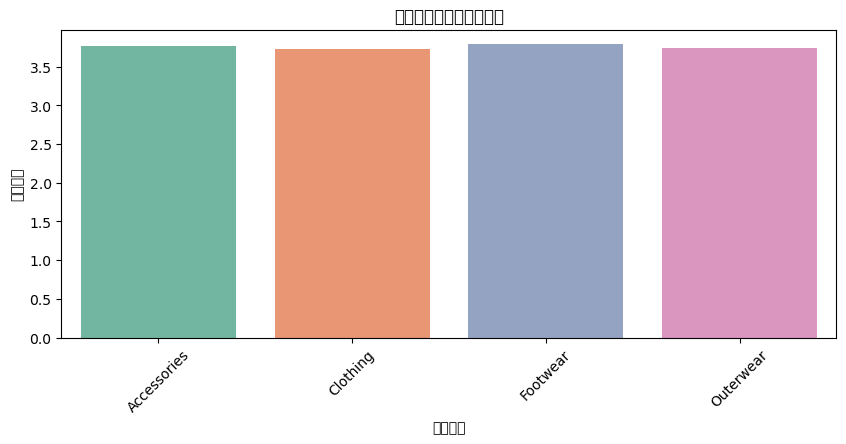

In [3]:
# 不同商品类别的平均评分
cat_rating = df.groupby('Category')['Review Rating'].mean().reset_index()
plt.figure(figsize=(10,4))
sns.barplot(x='Category', y='Review Rating', data=cat_rating, palette='Set2')
plt.title('不同商品类别的平均评分')
plt.xlabel('商品类别')
plt.ylabel('平均评分')
plt.xticks(rotation=45)
plt.show()

## 评分与消费金额的关联分析

分析不同消费金额区间的平均评分，评估高低消费客户满意度。

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_34932\1350031877.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_rating = df.groupby('AmountBin')['Review Rating'].mean().reset_index()
C:\Users\xuzijian\AppData\Local\Temp\ipykernel_34932\1350031877.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AmountBin', y='Review Rating', data=amount_rating, palette='Set3')
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22

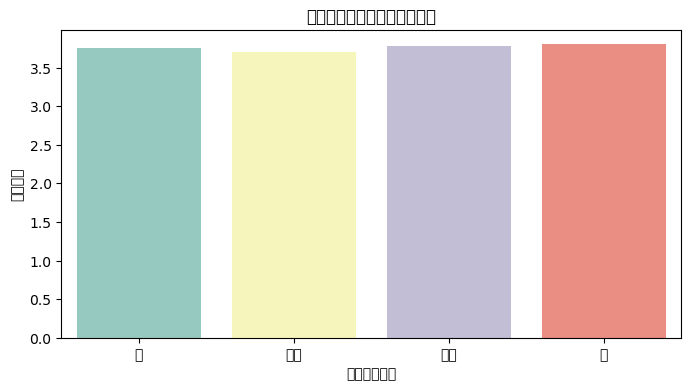

In [4]:
# 消费金额分箱与平均评分
df['AmountBin'] = pd.cut(df['Purchase Amount (USD)'], bins=[0,30,60,90,120], labels=['低','中低','中高','高'])
amount_rating = df.groupby('AmountBin')['Review Rating'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(x='AmountBin', y='Review Rating', data=amount_rating, palette='Set3')
plt.title('不同消费金额区间的平均评分')
plt.xlabel('消费金额区间')
plt.ylabel('平均评分')
plt.show()

## 不同购买频率客户的满意度分析

分析不同购买频率客户的平均评分，洞察忠诚客户满意度。

C:\Users\xuzijian\AppData\Local\Temp\ipykernel_34932\301583155.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency of Purchases', y='Review Rating', data=freq_rating, palette='Set1')
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

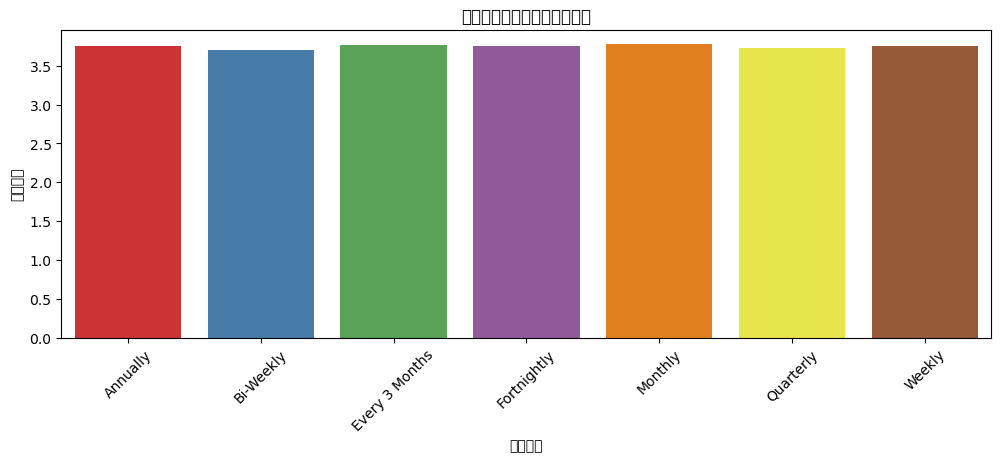

In [5]:
# 不同购买频率的平均评分
freq_rating = df.groupby('Frequency of Purchases')['Review Rating'].mean().reset_index()
plt.figure(figsize=(12,4))
sns.barplot(x='Frequency of Purchases', y='Review Rating', data=freq_rating, palette='Set1')
plt.title('不同购买频率客户的平均评分')
plt.xlabel('购买频率')
plt.ylabel('平均评分')
plt.xticks(rotation=45)
plt.show()

## 结论与建议

- 客户整体满意度较高，但不同商品类别和消费金额区间存在显著差异。
- 高频购买客户满意度更高，忠诚客户体验较好。
- 部分类别和低消费客户评分偏低，需重点优化服务和产品。

建议：针对低评分类别和客户群体，优化产品质量和服务流程，提升整体满意度。